In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'agricultural_supply_chain_dataset.csv'  # Adjust the path if needed
data = pd.read_csv(file_path)

C:\Users\jasmi\AppData\Local\Temp\ipykernel_24468\837729678.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data

,Product Name,Supplier Location,Quantity,Blockchain Transaction ID,Transportation Mode,Production Date,Transaction Date,Delivery Date,Soil Quality,Crop Health,pesticides used or not for growing crop,Total Supply Chain Days took to Deliver Product,Quality Assessment
0,Soybeans,Aurangabad,5398,0xcf7c1a856dbb810259b2d1fab6dc20fe95e840ef0b2e...,Truck,2022-10-02,2022-10-22,2022-11-11,High,Stunted,used,40,High
1,Rice,Navi Mumbai,9903,0x210808e207b1b301261654371da4ddbfa748d3b3551b...,Air,2023-12-04,2024-01-08,2024-03-06,Medium,Stunted,not_used,93,Medium
2,Rice,Pune,7221,0x0ef10003600ece36c5dd8e9cfa35c5affaebbc6ce34c...,Ship,2021-06-04,2021-08-25,2021-11-22,High,Infected,not_used,171,Low
3,Wheat,Visakhapatnam,3427,0xfa168c7d5ba5e774fc44ee90fc2d38c3185df5275f9d...,Ship,2022-11-04,2022-11-25,2022-12-10,Low,Stunted,used,36,High
4,Lettuce,Kalyan-Dombivali,3126,0x4925f689bcb5b8dd235100c19dc3129f4624c6d7ad03...,Truck,2021-01-01,2021-03-08,2021-05-19,Medium,Infected,not_used,138,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Rice,Raipur,4507,0xbb1dad554f7f1613b4d8413c0009ad234323793fc28d...,Ship,2020-03-01,2020-03-30,2020-04-18,High,Healthy,not_used,48,High
1996,Tomatoes,Meerut,1627,0xf294f98d9828839914adeca12d733d7656b7b8dd15d4...,Ship,2022-10-06,2022-12-25,2023-02-25,High,Stunted,used,142,Low
1997,Rice,Nashik,9595,0x26765f2f5c54e547199e5e9356e875cd9e2ec43cd527...,Truck,2020-07-03,2020-09-22,2020-11-28,High,Stunted,not_used,148,Low
1998,Wheat,Indore,485,0xcf3ef73a2decf4a67851309fad466fc23a7058961147...,Ship,2023-10-06,2023-10-29,2023-11-11,Low,Healthy,not_used,36,High


In [5]:
# Convert date columns to datetime objects
date_columns = ['Production Date', 'Transaction Date', 'Delivery Date']
for col in date_columns:
    data[col] = pd.to_datetime(data[col], errors='coerce')

In [6]:
# Identifying columns for one-hot encoding and label encoding, excluding the target column 'Quality Assessment'
unique_values = {col: data[col].nunique() for col in data.columns if data[col].dtype == 'object' and col != 'Quality Assessment'}
one_hot_columns = [col for col, unique in unique_values.items() if unique <= 10]
label_encoding_columns = [col for col in unique_values.keys() if col not in one_hot_columns]


In [7]:
# One-Hot Encoding
data_one_hot_encoded = pd.get_dummies(data, columns=one_hot_columns)

In [8]:
# Displaying a snippet of the processed data
print(data_one_hot_encoded.head())

  Supplier Location  Quantity  \
0        Aurangabad      5398   
1       Navi Mumbai      9903   
2              Pune      7221   
3     Visakhapatnam      3427   
4  Kalyan-Dombivali      3126   

                           Blockchain Transaction ID Production Date  \
0  0xcf7c1a856dbb810259b2d1fab6dc20fe95e840ef0b2e...      2022-10-02   
1  0x210808e207b1b301261654371da4ddbfa748d3b3551b...      2023-12-04   
2  0x0ef10003600ece36c5dd8e9cfa35c5affaebbc6ce34c...      2021-06-04   
3  0xfa168c7d5ba5e774fc44ee90fc2d38c3185df5275f9d...      2022-11-04   
4  0x4925f689bcb5b8dd235100c19dc3129f4624c6d7ad03...      2021-01-01   

  Transaction Date Delivery Date  \
0       2022-10-22    2022-11-11   
1       2024-01-08    2024-03-06   
2       2021-08-25    2021-11-22   
3       2022-11-25    2022-12-10   
4       2021-03-08    2021-05-19   

   Total Supply Chain Days took to Deliver Product Quality Assessment  \
0                                               40               High   
1    

In [9]:
# Label Encoding
label_encoder = LabelEncoder()
for col in label_encoding_columns:
    data_one_hot_encoded[col] = label_encoder.fit_transform(data_one_hot_encoded[col])

In [10]:
# Scaling the numerical variables
scaler = StandardScaler()
numerical_columns = ['Quantity', 'Total Supply Chain Days took to Deliver Product']
data_one_hot_encoded[numerical_columns] = scaler.fit_transform(data_one_hot_encoded[numerical_columns])

In [11]:
# Export the processed dataset to a new CSV (optional)
data_one_hot_encoded.to_csv('processed_agricultural_supply_chain_dataset.csv', index=False)

# Displaying a snippet of the processed data
print(data_one_hot_encoded.head())


   Supplier Location  Quantity  Blockchain Transaction ID Production Date  \
0                  4  0.172996                       1595      2022-10-02   
1                 33  1.734774                        269      2023-12-04   
2                 35  0.804987                        125      2021-06-04   
3                 46 -0.510304                       1953      2022-11-04   
4                 22 -0.614654                        565      2021-01-01   

  Transaction Date Delivery Date  \
0       2022-10-22    2022-11-11   
1       2024-01-08    2024-03-06   
2       2021-08-25    2021-11-22   
3       2022-11-25    2022-12-10   
4       2021-03-08    2021-05-19   

   Total Supply Chain Days took to Deliver Product Quality Assessment  \
0                                        -1.123246               High   
1                                        -0.009311             Medium   
2                                         1.630065                Low   
3                           

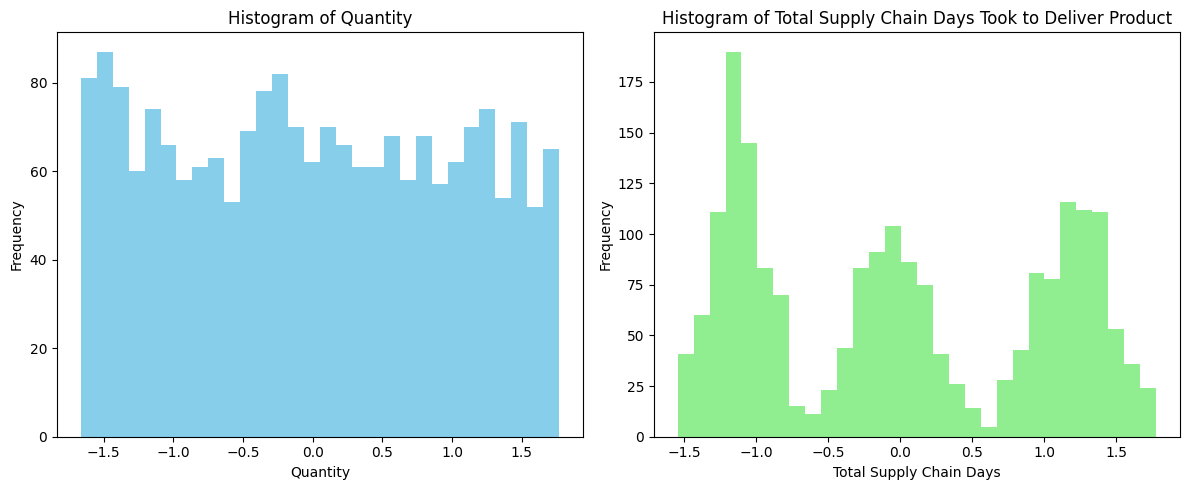

In [12]:
# Plotting histograms for the numerical variables
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Quantity
ax[0].hist(data_one_hot_encoded['Quantity'], bins=30, color='skyblue')
ax[0].set_title('Histogram of Quantity')
ax[0].set_xlabel('Quantity')
ax[0].set_ylabel('Frequency')

# Histogram for Total Supply Chain Days
ax[1].hist(data_one_hot_encoded['Total Supply Chain Days took to Deliver Product'], bins=30, color='lightgreen')
ax[1].set_title('Histogram of Total Supply Chain Days Took to Deliver Product')
ax[1].set_xlabel('Total Supply Chain Days')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots are displayed inline in the Jupyter Notebook
%matplotlib inline

# Load the preprocessed dataset
file_path = 'agricultural_supply_chain_dataset.csv'  # Adjust the path if needed
data = pd.read_csv(file_path)

# Basic Summary of the Dataset
print("Basic Summary:")
print(data.describe())




Basic Summary:
          Quantity  Total Supply Chain Days took to Deliver Product
count  2000.000000                                      2000.000000
mean   4898.988000                                        93.443000
std    2885.253226                                        47.590989
min     100.000000                                        20.000000
25%    2381.500000                                        45.000000
50%    4812.500000                                        90.000000
75%    7385.500000                                       144.000000
max    9999.000000                                       178.000000


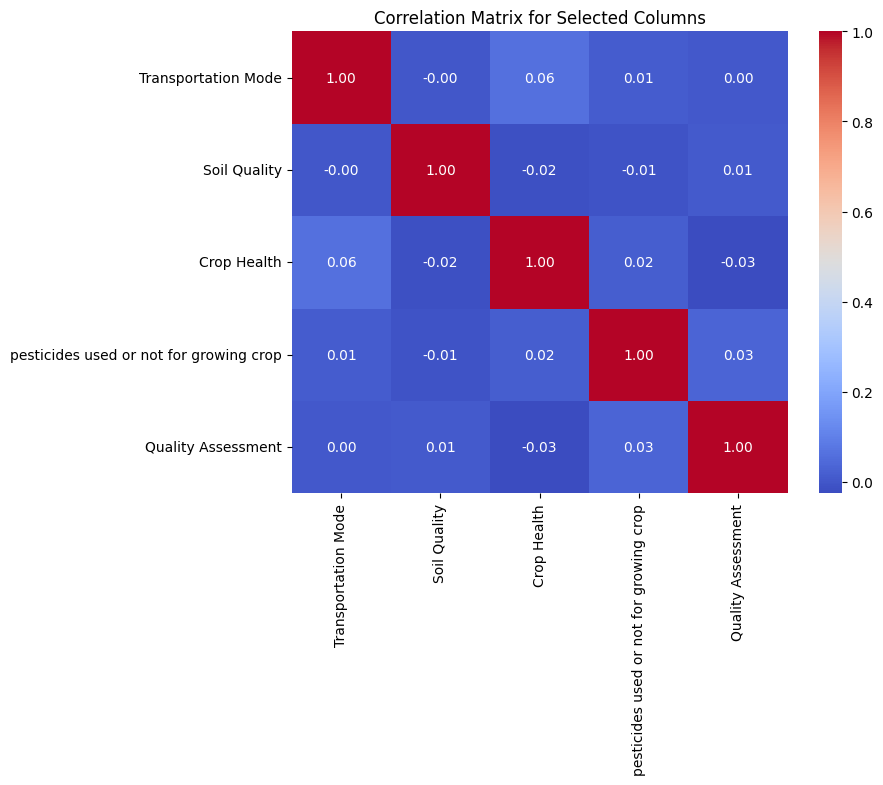

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load your dataset
file_path = 'agricultural_supply_chain_dataset.csv'  # Replace with your dataset file path
df = pd.read_csv(file_path)

# Encoding categorical variables to numeric for correlation calculation
label_encoders = {}
categorical_columns = ['Transportation Mode', 'Soil Quality', 'Crop Health', 'pesticides used or not for growing crop','Quality Assessment']

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Calculating the correlation matrix for the selected columns
corr_matrix = df[categorical_columns].corr()

# Plotting the heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Selected Columns')
plt.show()


c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


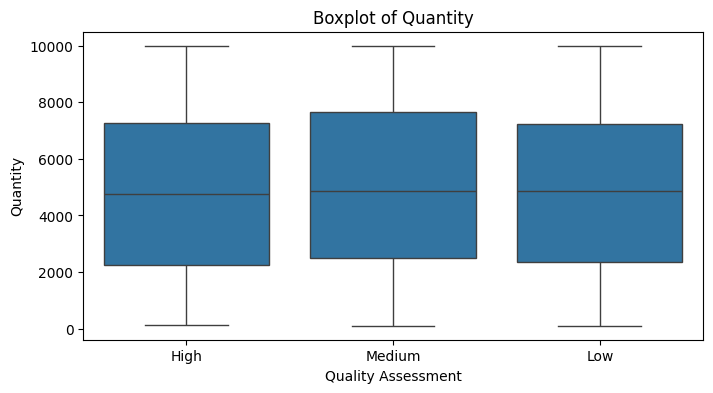

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


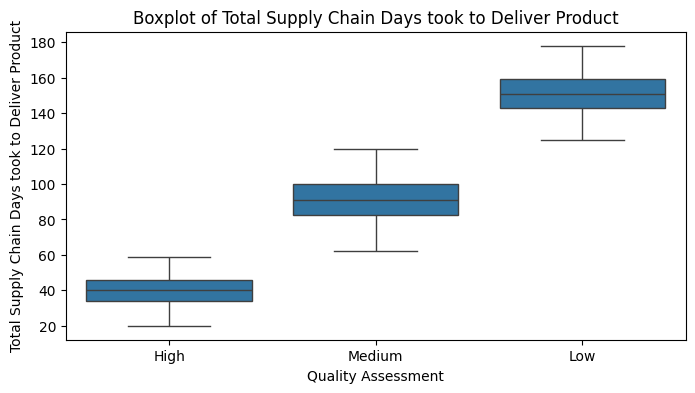

In [15]:
# Boxplots for each numerical variable
for column in ['Quantity', 'Total Supply Chain Days took to Deliver Product']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Quality Assessment', y=column, data=data)
    plt.title(f'Boxplot of {column}')
    plt.show()



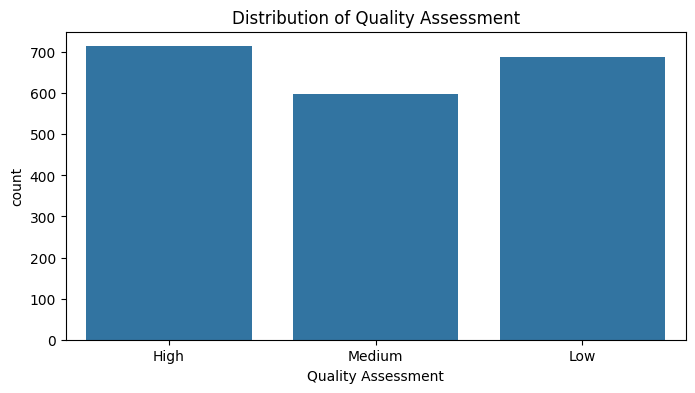

In [16]:
# Distribution of the Target Variable
plt.figure(figsize=(8, 4))
sns.countplot(x='Quality Assessment', data=data)
plt.title('Distribution of Quality Assessment')
plt.show()


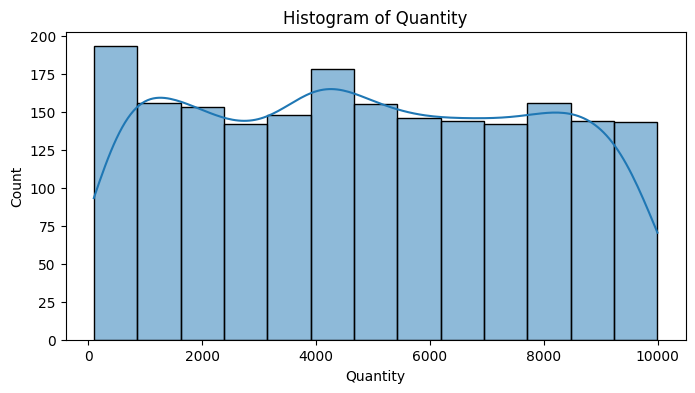

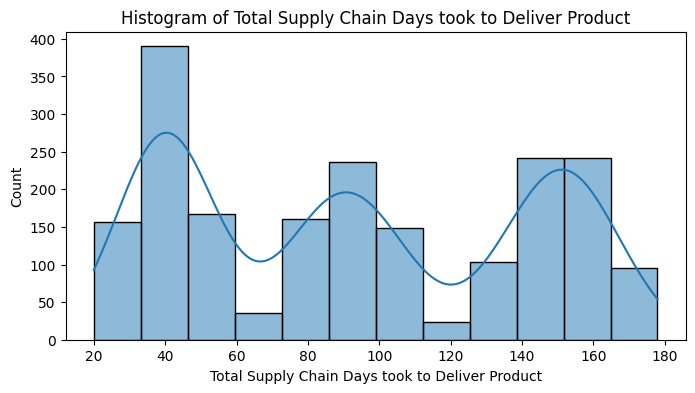

In [17]:
# Additional Visualizations
# Histograms for each numerical variable
for column in ['Quantity', 'Total Supply Chain Days took to Deliver Product']:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.show()



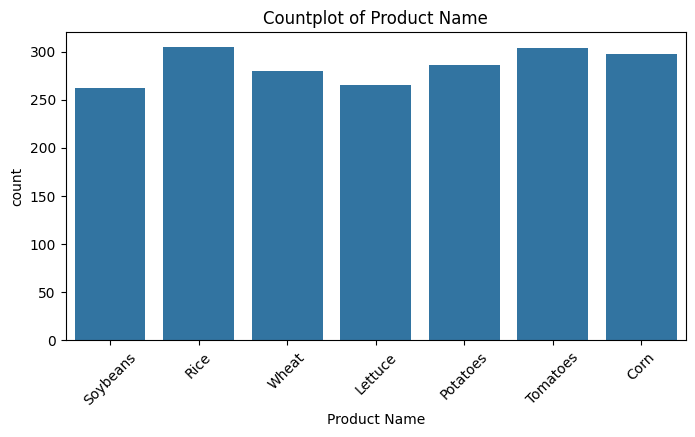

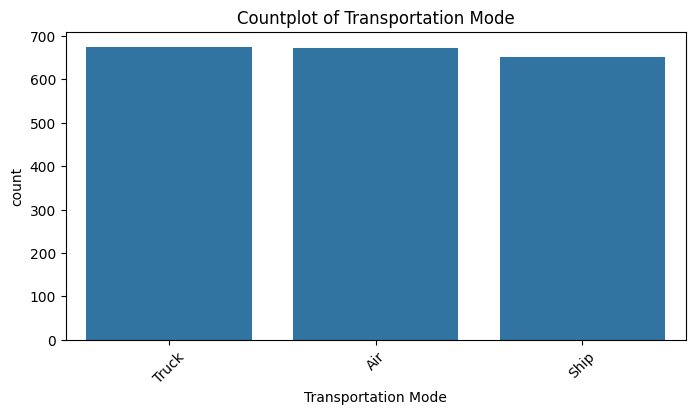

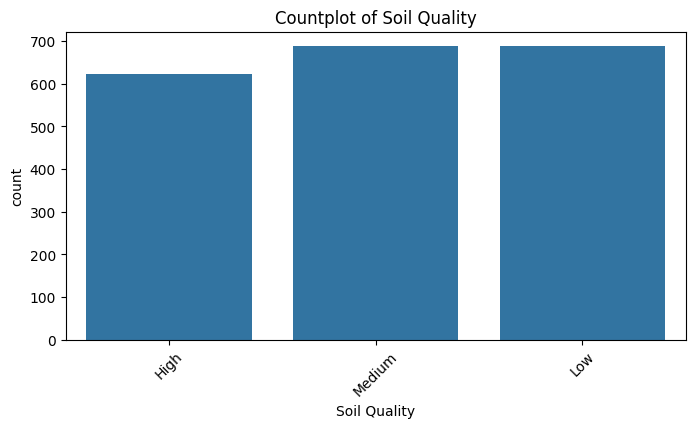

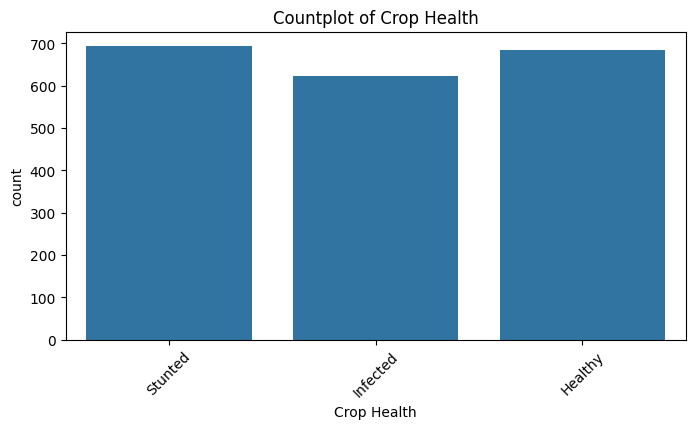

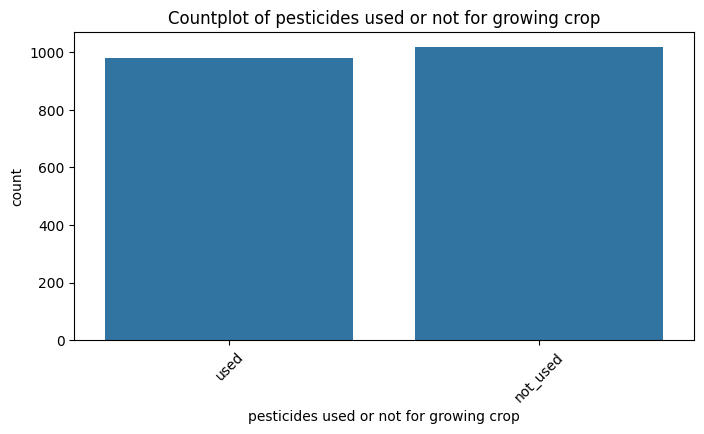

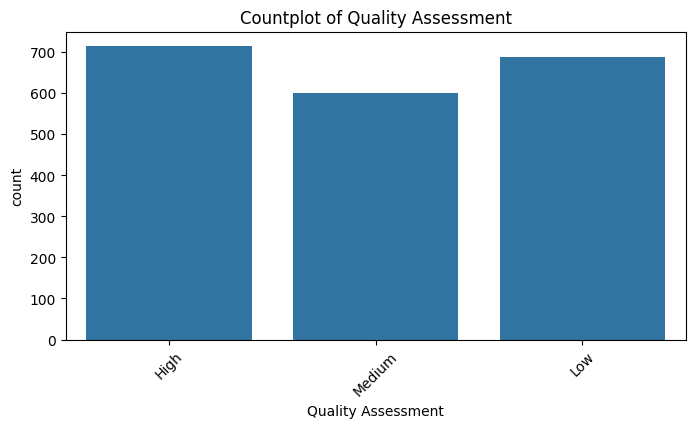

In [18]:
# Countplots for selected categorical variables
# List of columns to exclude
exclude_columns = ['Blockchain Transaction ID', 'Production Date', 'Transaction Date', 'Delivery Date','Supplier Location']

# Filtering out the excluded columns
categorical_columns = data.select_dtypes(include=['object', 'category']).columns
categorical_columns = [col for col in categorical_columns if col not in exclude_columns]

# Generating countplots for each categorical column
for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=column, data=data)
    plt.title(f'Countplot of {column}')
    plt.xticks(rotation=45)
    plt.show()

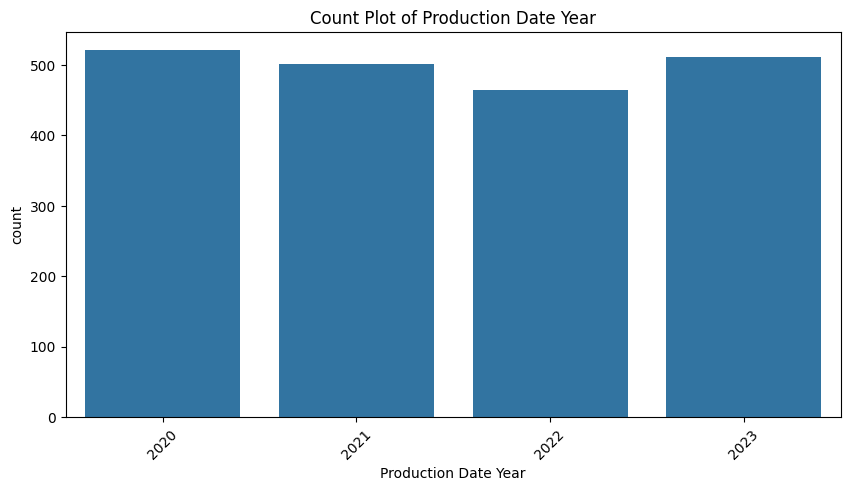

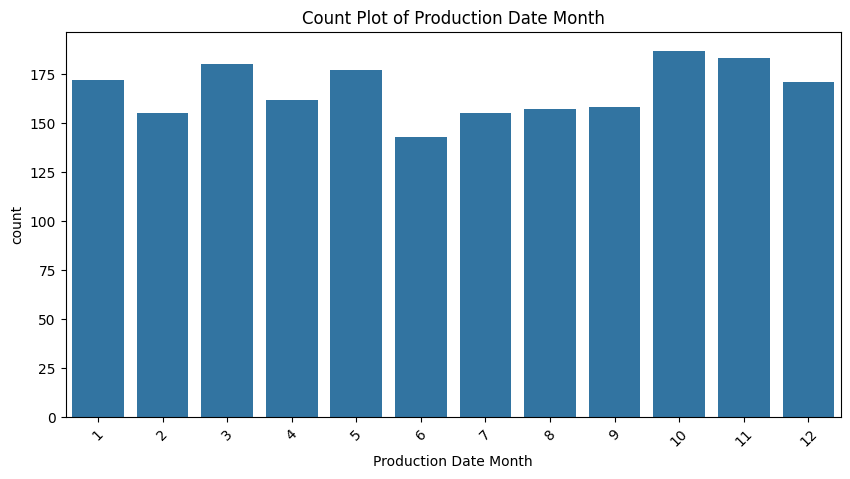

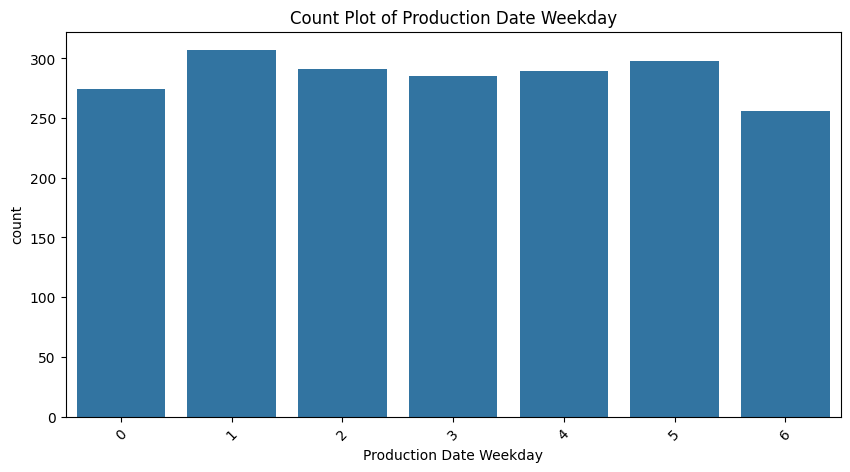

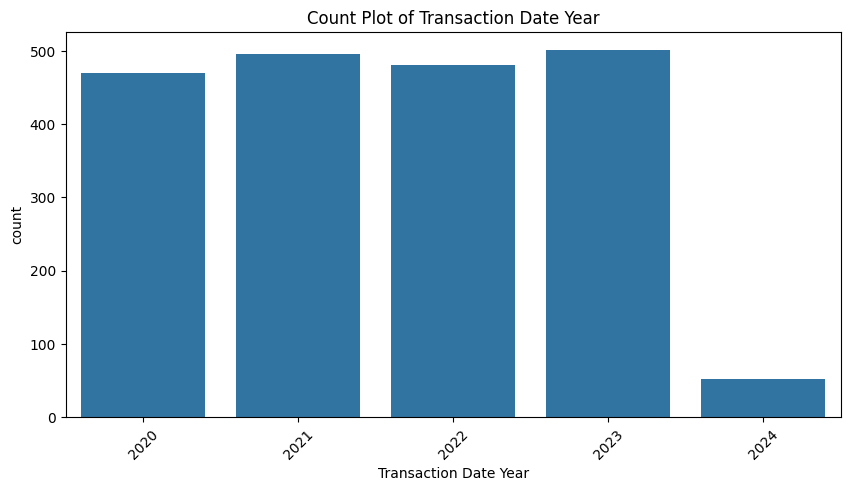

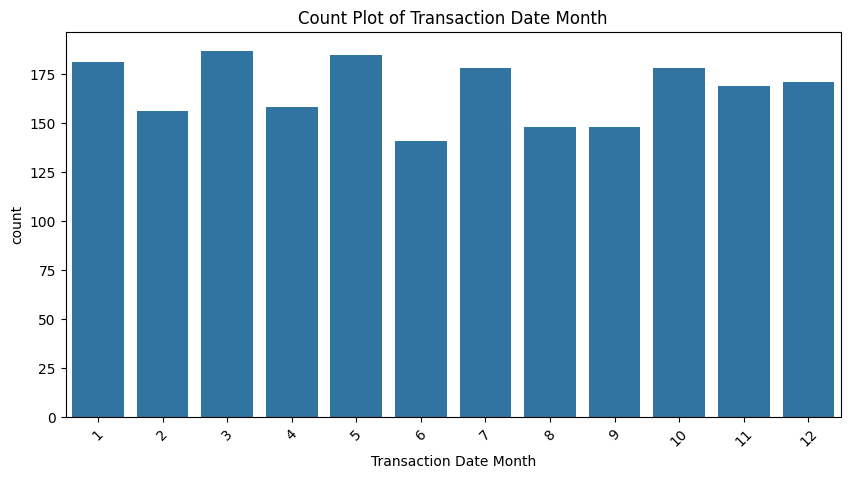

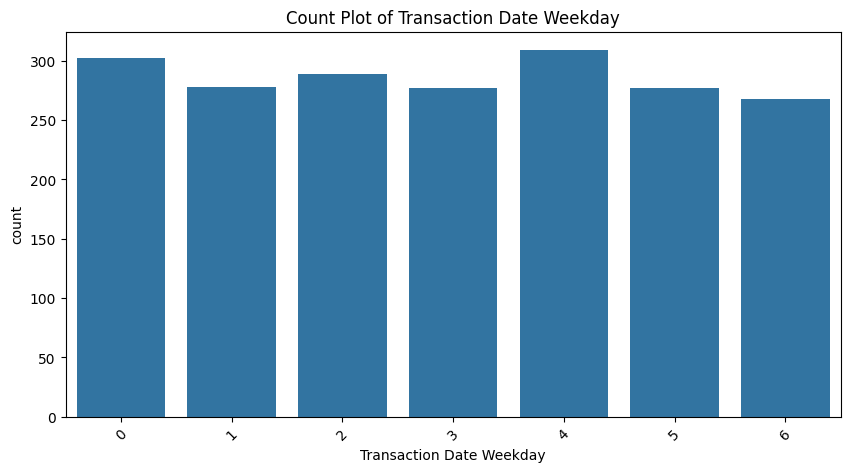

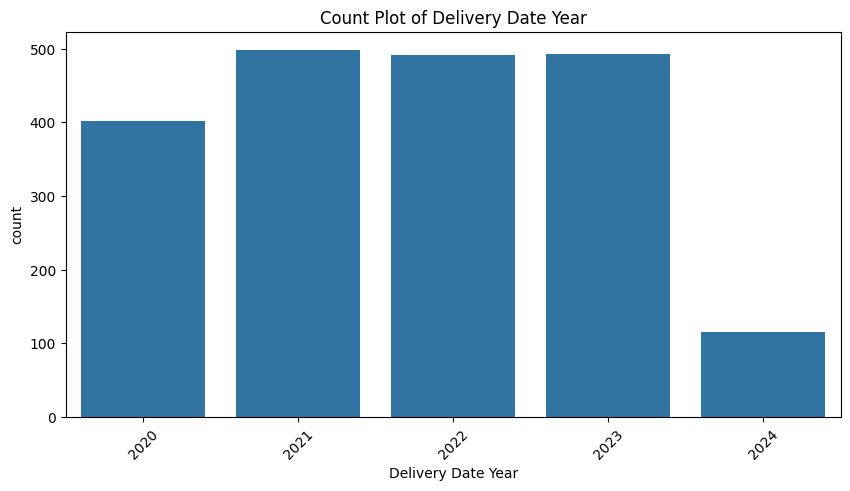

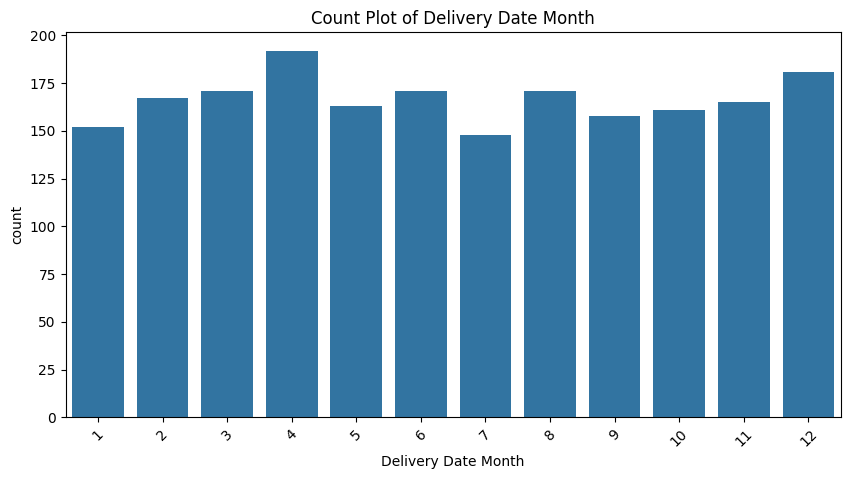

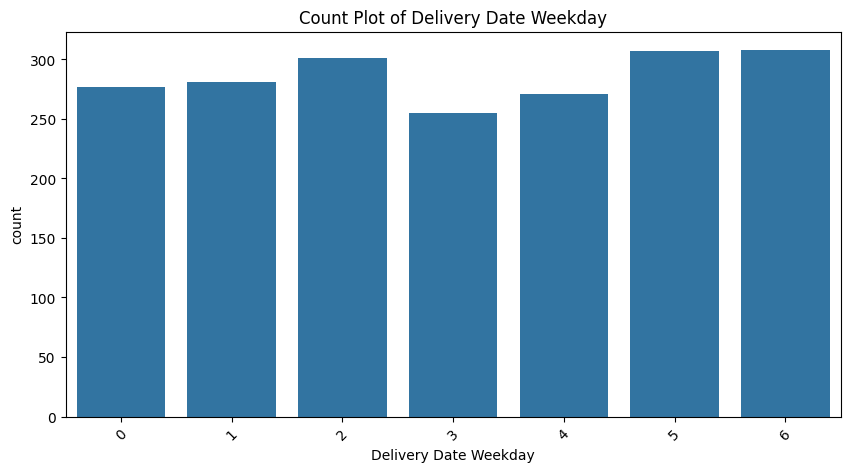

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Load the preprocessed dataset
file_path = 'agricultural_supply_chain_dataset.csv'  # Adjust the path if needed
data = pd.read_csv(file_path)

# Convert date columns to datetime and extract year, month, and day of the week
date_columns = ['Production Date', 'Transaction Date', 'Delivery Date']
for col in date_columns:
    data[col] = pd.to_datetime(data[col])
    data[f'{col} Year'] = data[col].dt.year
    data[f'{col} Month'] = data[col].dt.month
    data[f'{col} Weekday'] = data[col].dt.weekday

# Extract features from date columns
extracted_features = [f'{col} {feature}' for col in date_columns for feature in ['Year', 'Month', 'Weekday']]

# Plot count plots for each feature
for feature in extracted_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=feature, data=data)
    plt.title(f'Count Plot of {feature}')
    plt.xticks(rotation=45)
    plt.show()

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

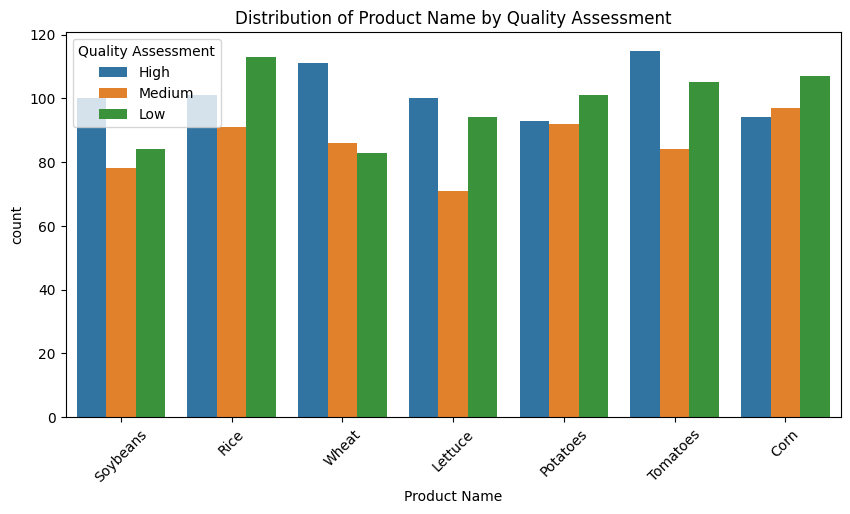

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

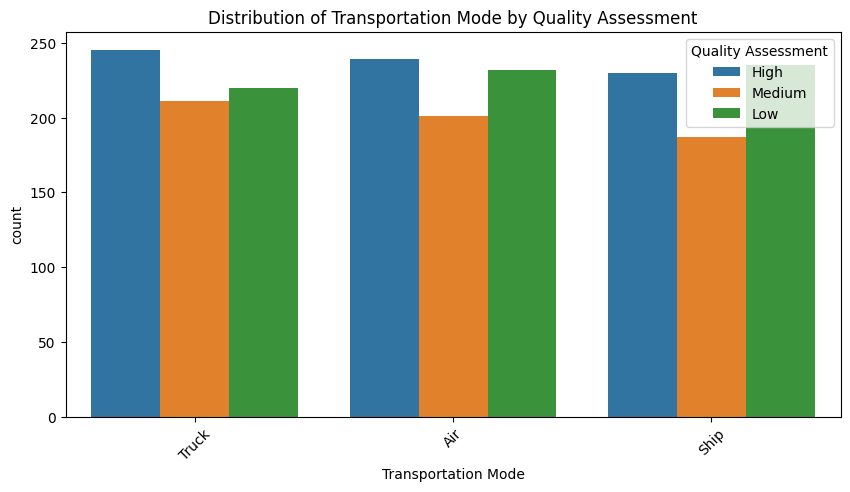

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

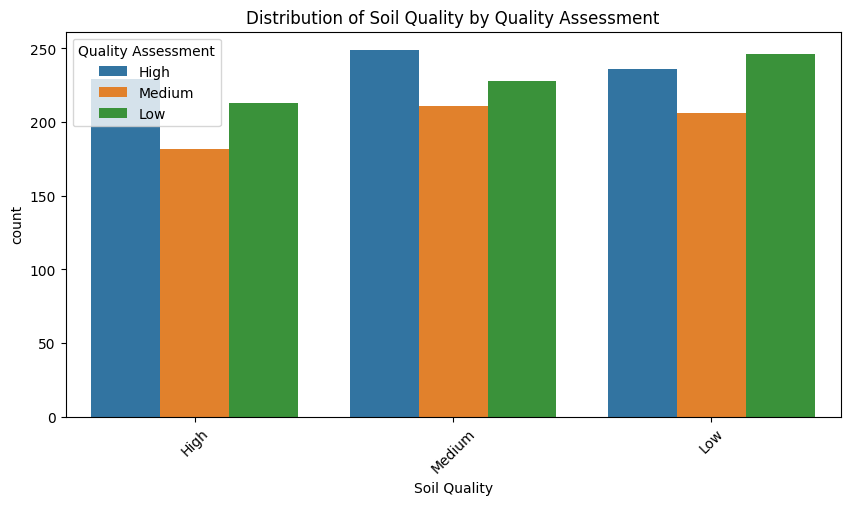

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

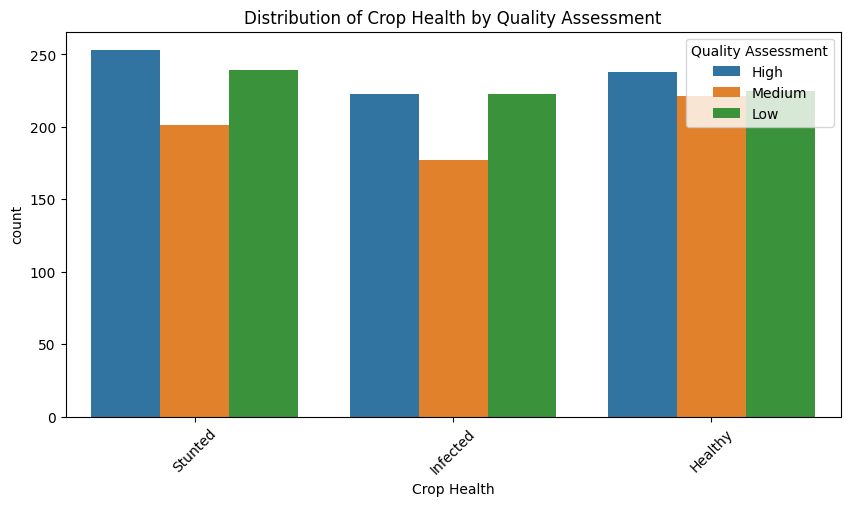

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

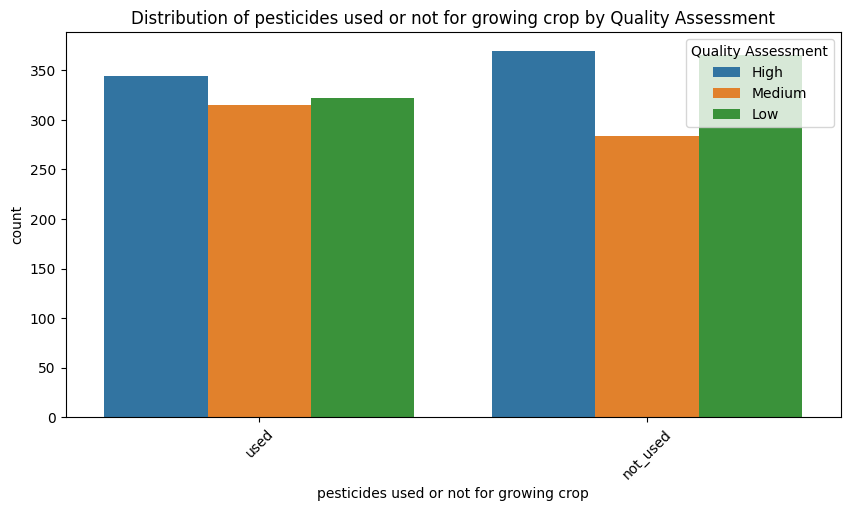

In [20]:
# Bar plots for categorical variables
categorical_columns = ['Product Name', 'Transportation Mode', 'Soil Quality', 'Crop Health', 'pesticides used or not for growing crop']
for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=column, hue='Quality Assessment', data=data)
    plt.title(f'Distribution of {column} by Quality Assessment')
    plt.xticks(rotation=45)
    plt.show()

# Note: Modify this code to focus on specific aspects of your dataset or to include other visualizations of interest.

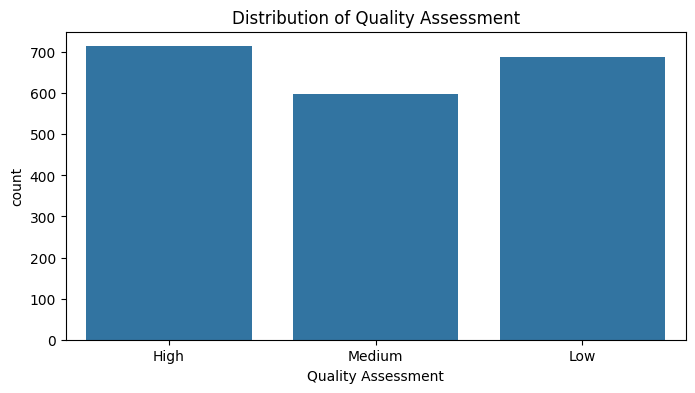

In [21]:
# Distribution of the Target Variable (Quality Assessment)
plt.figure(figsize=(8, 4))
sns.countplot(x='Quality Assessment', data=data)
plt.title('Distribution of Quality Assessment')
plt.show()

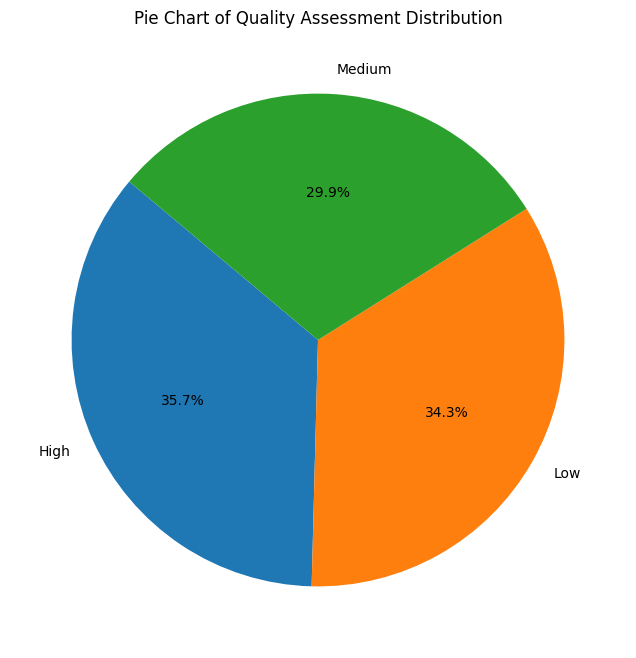

In [22]:
# Pie Chart for the Distribution of 'Quality Assessment'
quality_counts = data['Quality Assessment'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(quality_counts, labels=quality_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Quality Assessment Distribution')
plt.show()

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

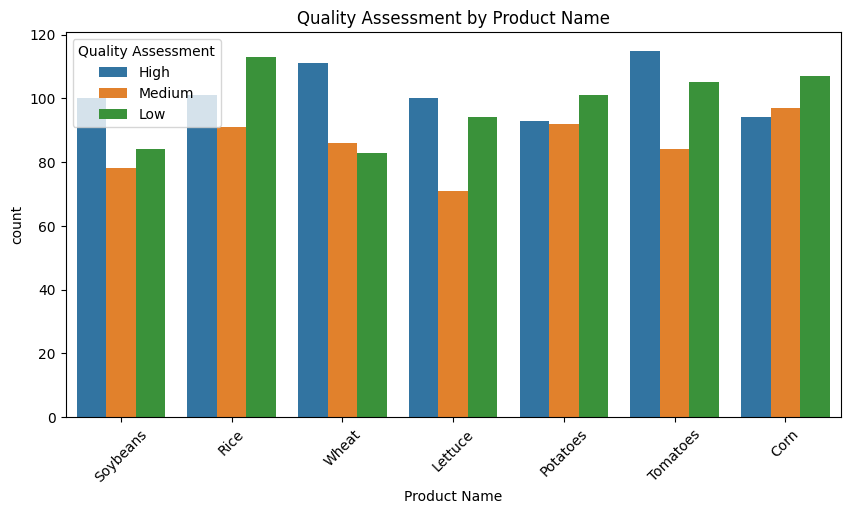

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

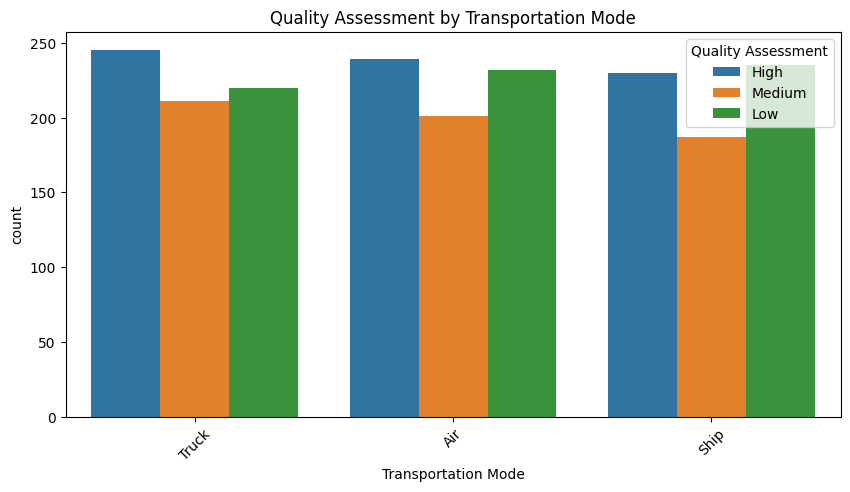

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

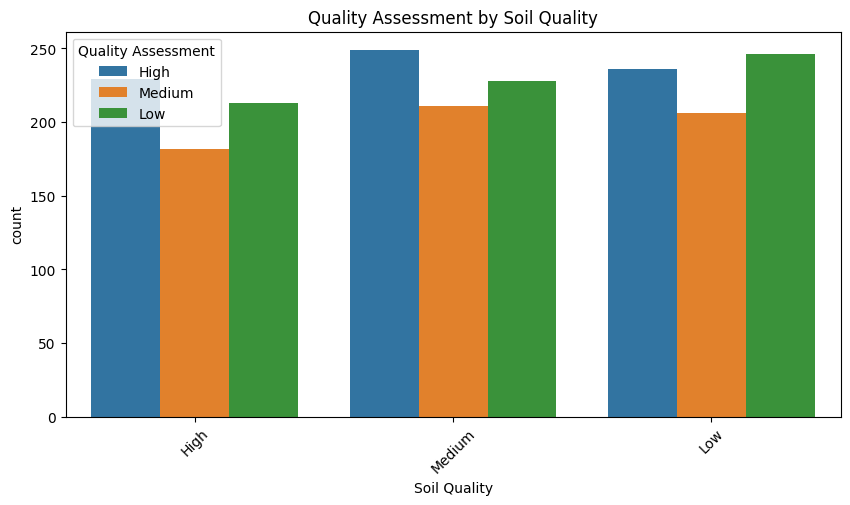

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

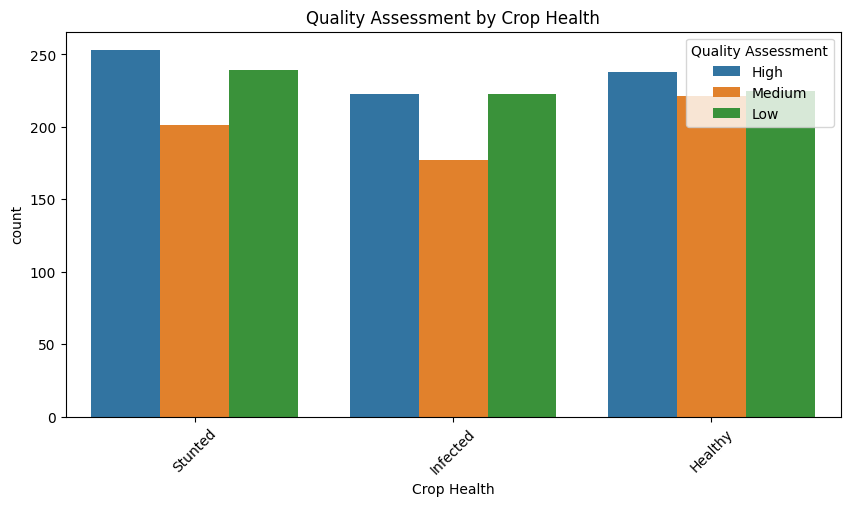

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

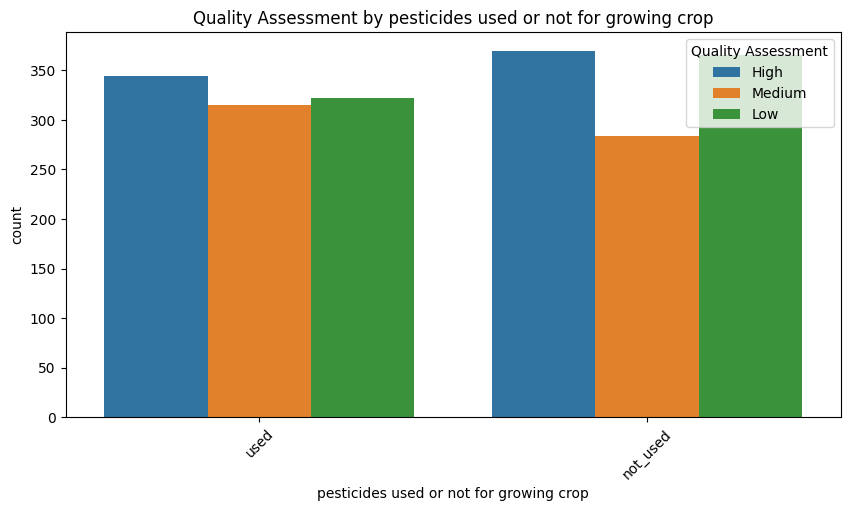

In [23]:
# Analysis of Quality by Different Factors
factors = ['Product Name', 'Transportation Mode', 'Soil Quality', 'Crop Health', 'pesticides used or not for growing crop']
for factor in factors:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=factor, hue='Quality Assessment', data=data)
    plt.title(f'Quality Assessment by {factor}')
    plt.xticks(rotation=45)
    plt.show()



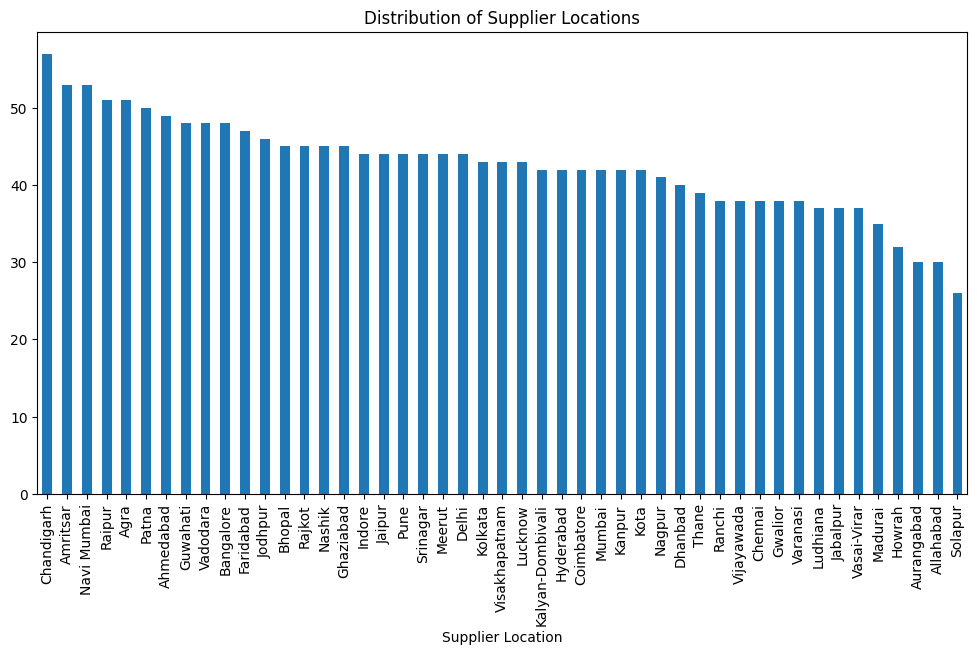

In [24]:
# Supplier Location Analysis
plt.figure(figsize=(12, 6))
data['Supplier Location'].value_counts().plot(kind='bar')
plt.title('Distribution of Supplier Locations')
plt.xticks(rotation=90)
plt.show()

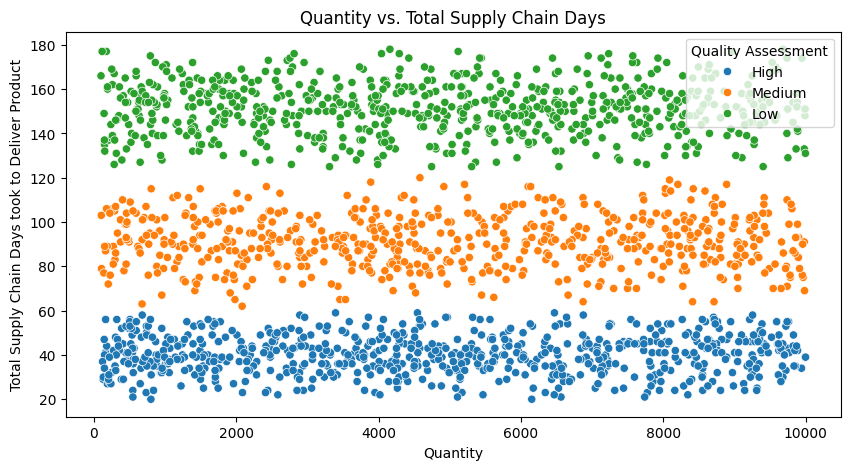

In [25]:
# Relationship between Quantity and Total Supply Chain Days
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Quantity', y='Total Supply Chain Days took to Deliver Product', hue='Quality Assessment', data=data)
plt.title('Quantity vs. Total Supply Chain Days')
plt.show()

# Note: Continue to add or modify visualizations based on your specific areas of interest or hypothesis.

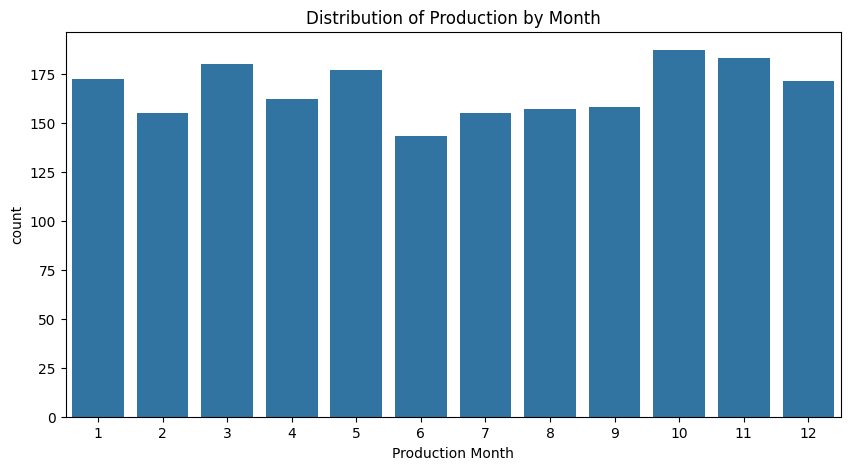

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots are displayed inline in the Jupyter Notebook
%matplotlib inline

# Load the dataset
file_path = 'processed_agricultural_supply_chain_dataset.csv'  # Adjust the path if needed
data = pd.read_csv(file_path)

# Convert 'Production Date' to datetime format, if not already
data['Production Date'] = pd.to_datetime(data['Production Date'], errors='coerce')

# Extract the month from 'Production Date'
data['Production Month'] = data['Production Date'].dt.month

# Time Series Analysis
plt.figure(figsize=(10, 5))
sns.countplot(x='Production Month', data=data)
plt.title('Distribution of Production by Month')
plt.show()


In [27]:
# Load the preprocessed dataset
file_path = 'processed_agricultural_supply_chain_dataset.csv'  # Adjust the path if needed
data = pd.read_csv(file_path)
# Convert all date columns to a numerical format or remove them
data['Production Date'] = pd.to_datetime(data['Production Date'])
data['Transaction Date'] = pd.to_datetime(data['Transaction Date'])  # Example for another date column
data['Delivery Date'] = pd.to_datetime(data['Delivery Date'])        # Example for another date column

reference_date = pd.Timestamp('2020-01-01')
data['Days Since Production'] = (data['Production Date'] - reference_date).dt.days
data['Days Since Transaction'] = (data['Transaction Date'] - reference_date).dt.days  # Convert Transaction Date
data['Days Since Delivery'] = (data['Delivery Date'] - reference_date).dt.days       # Convert Delivery Date

# Drop the original date columns
data.drop(['Production Date', 'Transaction Date', 'Delivery Date','Blockchain Transaction ID'], axis=1, inplace=True)


In [28]:
data.head()

,Supplier Location,Quantity,Total Supply Chain Days took to Deliver Product,Quality Assessment,Product Name_Corn,Product Name_Lettuce,Product Name_Potatoes,Product Name_Rice,Product Name_Soybeans,Product Name_Tomatoes,...,Soil Quality_Low,Soil Quality_Medium,Crop Health_Healthy,Crop Health_Infected,Crop Health_Stunted,pesticides used or not for growing crop_not_used,pesticides used or not for growing crop_used,Days Since Production,Days Since Transaction,Days Since Delivery
0,4,0.172996,-1.123246,High,False,False,False,False,True,False,...,False,False,False,False,True,False,True,1005,1025,1045
1,33,1.734774,-0.009311,Medium,False,False,False,True,False,False,...,False,True,False,False,True,True,False,1433,1468,1526
2,35,0.804987,1.630065,Low,False,False,False,True,False,False,...,False,False,False,True,False,True,False,520,602,691
3,46,-0.510304,-1.207316,High,False,False,False,False,False,False,...,True,False,False,False,True,False,True,1038,1059,1074
4,22,-0.614654,0.936483,Low,False,True,False,False,False,False,...,False,True,False,True,False,True,False,366,432,504


In [29]:
# Encoding the target variable 'Quality Assessment'
label_encoder = LabelEncoder()
data['Quality Assessment'] = label_encoder.fit_transform(data['Quality Assessment'])

# Splitting the dataset into features and target variable
X = data.drop('Quality Assessment', axis=1)
y = data['Quality Assessment']

In [30]:
print(X)

      Supplier Location  Quantity  \
0                     4  0.172996   
1                    33  1.734774   
2                    35  0.804987   
3                    46 -0.510304   
4                    22 -0.614654   
...                 ...       ...   
1995                 36 -0.135893   
1996                 29 -1.134322   
1997                 32  1.627998   
1998                 18 -1.530227   
1999                 40 -0.874315   

      Total Supply Chain Days took to Deliver Product  Product Name_Corn  \
0                                           -1.123246              False   
1                                           -0.009311              False   
2                                            1.630065              False   
3                                           -1.207316              False   
4                                            0.936483              False   
...                                               ...                ...   
1995                   

In [31]:
print(y)

0       0
1       2
2       1
3       0
4       1
       ..
1995    0
1996    1
1997    1
1998    0
1999    2
Name: Quality Assessment, Length: 2000, dtype: int32


Logistic Regression Performance:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       213
           1       0.99      1.00      1.00       210
           2       1.00      0.98      0.99       177

    accuracy                           0.99       600
   macro avg       1.00      0.99      0.99       600
weighted avg       1.00      0.99      0.99       600

Confusion Matrix:


c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


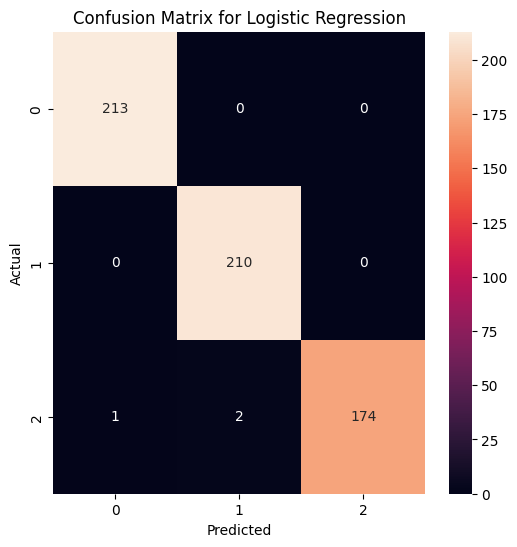

------------------------------------------------------------
Decision Tree Performance:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       213
           1       1.00      1.00      1.00       210
           2       1.00      1.00      1.00       177

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Confusion Matrix:


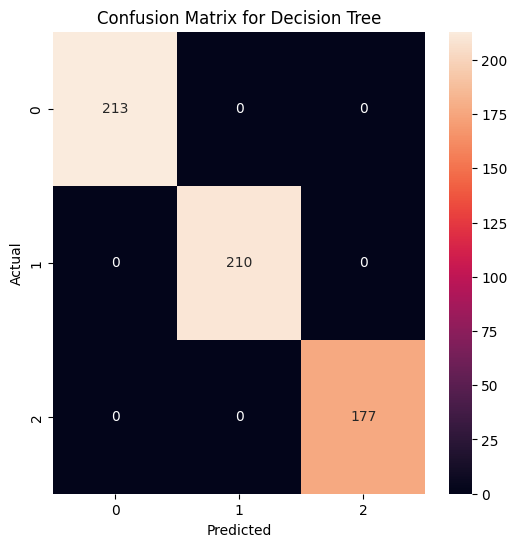

------------------------------------------------------------
Random Forest Performance:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       213
           1       1.00      1.00      1.00       210
           2       1.00      1.00      1.00       177

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Confusion Matrix:


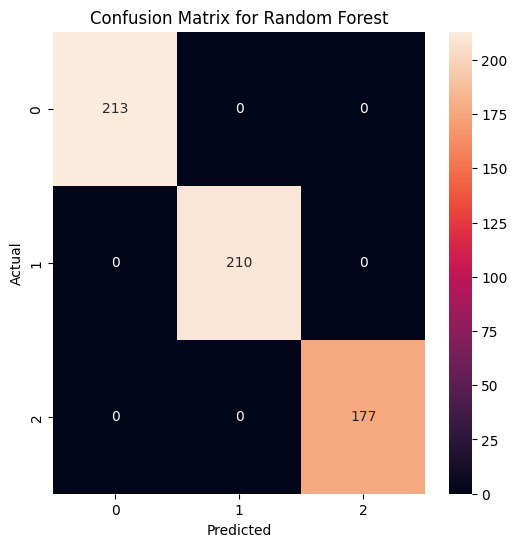

------------------------------------------------------------
Support Vector Machine Performance:
Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       213
           1       0.74      1.00      0.85       210
           2       0.00      0.00      0.00       177

    accuracy                           0.70       600
   macro avg       0.47      0.67      0.55       600
weighted avg       0.50      0.70      0.58       600

Confusion Matrix:


c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

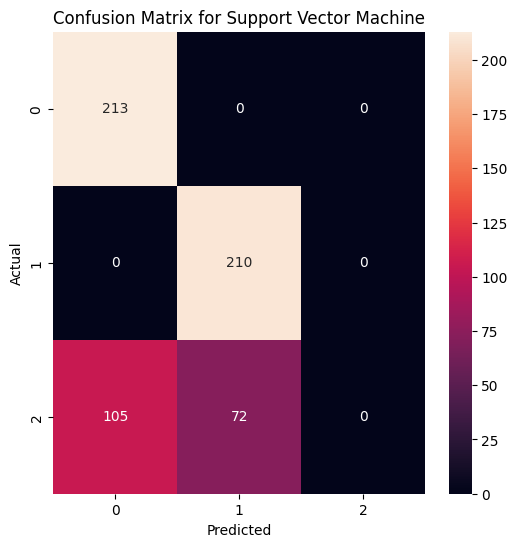

------------------------------------------------------------
K-Nearest Neighbors Performance:
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       213
           1       0.99      1.00      0.99       210
           2       0.99      0.96      0.97       177

    accuracy                           0.98       600
   macro avg       0.99      0.98      0.98       600
weighted avg       0.99      0.98      0.98       600

Confusion Matrix:


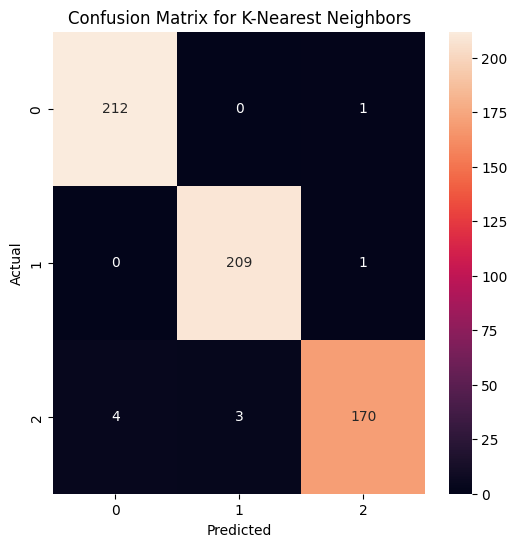

------------------------------------------------------------


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots are displayed inline in the Jupyter Notebook
%matplotlib inline


# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Function to train and evaluate models
def train_and_evaluate(models, X_train, y_train, X_test, y_test):
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        print(f"{name} Performance:")
        print("Classification Report:")
        print(classification_report(y_test, preds))
        print("Confusion Matrix:")
        cm = confusion_matrix(y_test, preds)
        plt.figure(figsize=(6, 6))
        sns.heatmap(cm, annot=True, fmt='g')
        plt.title(f'Confusion Matrix for {name}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        print("-" * 60)

# Training and evaluating models
train_and_evaluate(models, X_train, y_train, X_test, y_test)
